# Notebook 14 — Agentic RL II: The Agent Loop as an RL Environment

### Course roadmap

**Part I — classical RL** (`numpy` only)
1. Foundations & MDPs · 2. Dynamic Programming · 3. Monte Carlo & TD · 4. Function Approximation & DQN · 5. Policy Gradients · 6. Trust Regions & PPO

**Part II — RL for language models**
7. RLHF · 8. RLOO & RLVR · 9. GRPO & DeepSeek-R1 · 10. DPO & production libraries · 11. RLCD · 12 / 12.2 / 12.3. Teaching a small model to reason (GRPO, RLCD, PPO)

**Part III — Agentic RL**
- 13. Agentic RL foundations: from reasoning to acting, and why agents need RL
- **14. The agent loop as an RL environment: multi-turn rollouts, tool calls, observation masking** ← *you are here*
- 15. Credit assignment across turns: trajectory vs step-level advantages, critics, process rewards
- 16. A real tool-using agent: Qwen2.5-0.5B + calculator, multi-turn GRPO in PyTorch and `trl`
- 17. Agentic RL at scale: reward hacking, async/off-policy rollouts, frameworks, open problems

This notebook uses **PyTorch** (CPU is plenty). The model is a tiny GRU language
model, so every experiment runs in under a minute, and nothing about the
algorithm is hidden.

### Recap

Notebook 13 argued *why* agents need RL and derived the key equation: the
policy gradient of a multi-turn trajectory sums over **the tokens the agent
wrote**, never the tokens the environment wrote. This notebook builds the whole
machinery for a token-level agent, from scratch:

1. **An environment with a text interface**: the agent writes tokens; when it
   closes a tool call, the environment writes the tool's (verbose) output into
   the same sequence.
2. **A batched multi-turn rollout engine** that records, for every token,
   *who wrote it*. That record is the **mask**.
3. **SFT warm start** on noisy teacher trajectories (notebook 13: RL needs a prior).
4. **Multi-turn GRPO** with observation masking.
5. Two experiments every agentic-RL practitioner should have seen once:
   - **forget the mask**, and learning stops;
   - **charge too much per tool call**, and the agent stops using tools.

## 1. Designing the environment interface

`gymnasium` environments (notebook 4) have `reset() → obs` and
`step(action) → obs, reward, done`. For an LLM agent the "action" is
**text**. So the environment needs a few more decisions, and each one is a
place where real systems have bugs:

| decision | the question | our choice (and the common one) |
|---|---|---|
| **action boundary** | when has the agent finished an action? | a stop token: `/CALL` ends a tool call, `<eos>` ends the episode (real systems: `</tool_call>`, `<|im_end|>`) |
| **parsing** | how are the call's arguments read? | strict: exactly one key between `CALL` and `/CALL` |
| **malformed calls** | what if the call can't be parsed? | return an error observation (`RES ERR /RES`) and let the agent continue. Errors are information, not crashes. |
| **observation format** | how does the tool result enter the context? | as tokens wrapped in `RES … /RES` (real: `<tool_response> … </tool_response>`, or a `tool` chat turn) |
| **budgets** | when do we stop a runaway agent? | at most `MAX_CALLS` tool calls and `MAX_LEN` tokens |
| **truncation** | what reward does an unfinished episode get? | 0. It never answered. (Some systems drop truncated episodes from the batch instead; see FAQ 3.) |
| **reward timing** | when is the reward given? | once, at the end (outcome reward) |

### The task: look up two values and add them

- The prompt names two keys, e.g. `Q k3 k6`.
- A hidden table assigns each of 8 keys a value in 0–4. **It's re-drawn for
  every episode**, so the answer can't be memorized. The agent *must* use
  the tool.
- Tool: `CALL k3 /CALL` → the environment returns something like
  `RES j7 j2 k3 = 4 j9 j1 j0 /RES`. Like a real API, the response is
  **verbose**: the useful part (`k3 = 4`) is surrounded by 4–8 random "junk"
  tokens (think timestamps, request ids and boilerplate JSON).
- Answer: `ANS 7 <eos>`. Reward 1 if the digit equals the sum of the two
  values, else 0.

In [1]:
import collections, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
torch.manual_seed(0); np.random.seed(0)

N_KEYS, N_VALS = 8, 5
SPECIAL = ["<pad>", "<bos>", "Q", "CALL", "/CALL", "RES", "/RES", "=", "ERR", "ANS", "<eos>"]
VOCAB = SPECIAL + [f"k{i}" for i in range(N_KEYS)] + [str(d) for d in range(10)] + [f"j{i}" for i in range(12)]
TOK = {t: i for i, t in enumerate(VOCAB)}
V = len(VOCAB)
PAD, BOS, Q, CALL, ECALL, RES, ERES, EQ, ERR, ANS, EOS = [TOK[t] for t in SPECIAL]
KEY0, DIG0, JUNK0, N_JUNK = TOK["k0"], TOK["0"], TOK["j0"], 12
MAX_LEN, MAX_CALLS, PROMPT_LEN = 72, 4, 4

def detok(ids):
    return " ".join(VOCAB[i] for i in ids)

class LookupEnv:
    '''Text environment. The agent writes one token at a time; the env answers tool calls with tokens.'''
    def __init__(self, rng, junk=(4, 8)):
        self.rng, self.junk = rng, junk

    def reset(self, task):
        self.ka, self.kb, self.table = task
        self.calls, self.malformed, self.done, self.reward = 0, 0, False, 0.0
        self.mode, self.buffer = None, []
        return [BOS, Q, KEY0 + self.ka, KEY0 + self.kb]          # the prompt

    def _tool(self, key):
        n = int(self.rng.integers(self.junk[0], self.junk[1] + 1))
        junk = list(JUNK0 + self.rng.integers(N_JUNK, size=n))
        cut = int(self.rng.integers(0, n + 1))                    # the useful part sits somewhere in the noise
        return [RES] + junk[:cut] + [KEY0 + key, EQ, DIG0 + int(self.table[key])] + junk[cut:] + [ERES]

    def agent_token(self, t):
        '''Consume one token written by the agent. Returns the tokens the environment writes next (often []).'''
        if self.mode == "call":
            if t != ECALL:
                self.buffer.append(t); return []
            self.mode, args, self.calls = None, self.buffer, self.calls + 1   # action boundary: execute the call
            if self.calls > MAX_CALLS:
                self.done = True; return []                          # budget exceeded: episode ends, reward 0
            if len(args) == 1 and KEY0 <= args[0] < KEY0 + N_KEYS:
                return self._tool(args[0] - KEY0)
            self.malformed += 1
            return [RES, ERR, ERES]                                  # malformed call: error observation
        if self.mode == "answer":
            if t != EOS:
                self.buffer.append(t); return []
            self.done = True
            target = int(self.table[self.ka] + self.table[self.kb])
            self.reward = float(len(self.buffer) == 1 and self.buffer[0] - DIG0 == target)
            return []
        if t == CALL:   self.mode, self.buffer = "call", []
        elif t == ANS:  self.mode, self.buffer = "answer", []
        elif t == EOS:  self.done = True                             # stopped without answering
        return []

def make_task(rng):
    ka, kb = rng.choice(N_KEYS, 2, replace=False)
    return int(ka), int(kb), rng.integers(N_VALS, size=N_KEYS)

# ---- drive the environment by hand, playing the agent ----
rng = np.random.default_rng(3)
env = LookupEnv(rng)
task = make_task(rng)
seq = env.reset(task)
print("prompt:      ", detok(seq), "   (hidden table:", dict(enumerate(task[2].tolist())), ")")
for t in [CALL, KEY0 + task[0], ECALL, CALL, KEY0 + task[1], ECALL]:
    obs = env.agent_token(t)
    if obs: print("tool output: ", detok(obs))
for t in [ANS, DIG0 + int(task[2][task[0]] + task[2][task[1]]), EOS]:
    env.agent_token(t)
print("reward:      ", env.reward)

prompt:       <bos> Q k0 k5    (hidden table: {0: 1, 1: 0, 2: 4, 3: 4, 4: 2, 5: 0, 6: 0, 7: 1} )
tool output:  RES k0 = 1 j7 j5 j3 j1 j8 j8 /RES
tool output:  RES j5 j4 k5 = 0 j10 j6 /RES
reward:       1.0


## 2. The policy: a tiny language model

A one-layer GRU, embedding size 128: about 100k parameters. It reads the
whole sequence (prompt, its own tokens and the tool outputs) and predicts the
next token, exactly like an LLM. The GRU's hidden state lets the rollout engine
feed tokens **one at a time**, the way a KV cache does for a transformer.

In [2]:
class TinyLM(nn.Module):
    def __init__(self, vocab_size, d=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d)
        self.rnn = nn.GRU(d, d, batch_first=True)
        self.head = nn.Linear(d, vocab_size)

    def forward(self, ids, h=None):
        out, h = self.rnn(self.emb(ids), h)
        return self.head(out), h

def token_logprobs(model, ids):
    '''log pi(token_{t+1} | tokens_<=t) for every position: shape (B, L-1).'''
    logits, _ = model(ids[:, :-1])
    return F.log_softmax(logits, -1).gather(-1, ids[:, 1:, None]).squeeze(-1)

def pad(seqs, masks):
    L = max(map(len, seqs))
    ids, m = torch.full((len(seqs), L), PAD), torch.zeros(len(seqs), L)
    for i, (s, mk) in enumerate(zip(seqs, masks)):
        ids[i, :len(s)] = torch.tensor(s); m[i, :len(mk)] = torch.tensor(mk, dtype=torch.float)
    return ids, m

print(f"TinyLM: {sum(p.numel() for p in TinyLM(V).parameters()):,} parameters, vocabulary {V}")

TinyLM: 109,609 parameters, vocabulary 41


## 3. The multi-turn rollout engine

This is the heart of every agentic-RL system. For a batch of episodes running
in parallel, at every position:

- if the environment has **pending output** for an episode (it just executed a
  tool call), the next token is **forced** from that queue and gets **mask 0**;
- otherwise the policy **samples** a token, which gets **mask 1**, and is handed
  to the environment, which may answer with a new queue of tokens.

Both kinds of token go through the model, because the agent must *read* the
tool output. Only the sampled ones are later trained on. Real systems do the
same thing at a coarser grain: generate until a stop string, run the tool,
append its output, continue generating (notebook 16). Here we do it at the
finest grain, so you can see that it's the same thing.

In [3]:
@torch.no_grad()
def rollout(model, tasks, rng, junk=(4, 8)):
    '''Run len(tasks) episodes in parallel. Returns token sequences, masks (1 = agent token) and env stats.'''
    B = len(tasks)
    envs = [LookupEnv(rng, junk) for _ in tasks]
    seqs = [e.reset(t) for e, t in zip(envs, tasks)]
    masks = [[0] * len(s) for s in seqs]                         # the prompt is not the agent's
    queues = [collections.deque() for _ in range(B)]             # env tokens waiting to be "read"
    logits, h = model(torch.tensor(seqs))
    for _ in range(MAX_LEN - PROMPT_LEN):
        active = [i for i in range(B) if not envs[i].done]
        if not active:
            break
        sampled = torch.multinomial(F.softmax(logits[:, -1], -1), 1).squeeze(1).tolist()
        nxt = [PAD] * B
        for i in active:
            if queues[i]:                                        # environment's turn: forced token, mask 0
                t, m = queues[i].popleft(), 0
            else:                                                # agent's turn: sampled token, mask 1
                t, m = sampled[i], 1
                queues[i].extend(envs[i].agent_token(t))
            seqs[i].append(t); masks[i].append(m); nxt[i] = t
        logits, h = model(torch.tensor(nxt)[:, None], h)         # feed one token per episode (like a KV cache)
    stats = {
        "reward": np.array([e.reward for e in envs]),
        "calls": np.array([min(e.calls, MAX_CALLS) for e in envs]),
        "truncated": np.array([not e.done for e in envs]),      # hit MAX_LEN without finishing
        "malformed": np.array([e.malformed for e in envs]),
    }
    return seqs, masks, stats

def show(seq, mask):
    '''Agent tokens plain, prompt in < >, environment tokens in [ ].'''
    out, i = [], 0
    while i < len(seq):
        j = i
        while j < len(seq) and mask[j] == mask[i]:
            j += 1
        chunk = detok(seq[i:j])
        out.append(chunk if mask[i] else (f"<{chunk}>" if i == 0 else f"[{chunk}]"))
        i = j
    return " ".join(out)

def evaluate(model, n=1024, seed=999):
    rng = np.random.default_rng(seed)
    _, _, s = rollout(model, [make_task(rng) for _ in range(n)], rng)
    by_calls = {c: (float((s["calls"] == c).mean()), float(s["reward"][s["calls"] == c].mean()) if (s["calls"] == c).any() else float("nan"))
                for c in range(MAX_CALLS + 1)}
    return float(s["reward"].mean()), float(s["calls"].mean()), by_calls

untrained = TinyLM(V)
seqs, masks, _ = rollout(untrained, [make_task(np.random.default_rng(1))], np.random.default_rng(1))
print("an untrained policy's episode:\n ", show(seqs[0], masks[0])[:300])

an untrained policy's episode:
  <<bos> Q k3 k4> j6 k1 j1 <bos> j10 j3 k4 j2 j3 j9 j9 k4 ANS j6 7 j5 5 ANS j9 j10 j11 3 k7 CALL j10 4 <bos> 3 k1 j10 k4 8 k0 k4 RES RES j2 k0 j5 2 k4 /RES Q 7 k0 j6 1 /CALL 6 k4 = k7 RES j7 <bos> = k1 k6 k6 2 CALL j11 ERR 9 k6 j1 ERR 2


An untrained policy writes random tokens until it happens to emit `<eos>` or
runs out of budget. Before RL, it needs a prior.

## 4. SFT warm start on a noisy teacher

As in notebooks 8 and 13, we create a base model by **SFT on imperfect
demonstrations**. That's the typical situation: trajectories from a weaker
model, or an inconsistent mix of strategies. The teacher's three habits:

| style | share | behavior | success |
|---|---|---|---|
| guess | 45% | answers immediately, no tool | ≈ 11% |
| one lookup | 35% | looks up the first key, guesses the rest | ≈ 20% |
| full | 20% | looks up both keys, adds | 100% |

**SFT uses the mask too.** The cross-entropy is computed only on the
teacher's (agent's) tokens. Training the student to predict tool outputs
would teach it to *imagine* tool results instead of reading them.

In [4]:
def teacher_episode(task, rng, style):
    env = LookupEnv(rng)
    seq = env.reset(task); mask = [0] * len(seq)
    def say(tokens):
        for t in tokens:
            seq.append(t); mask.append(1)
            obs = env.agent_token(t)
            seq.extend(obs); mask.extend([0] * len(obs))
    ka, kb, table = task
    if style == "guess":
        say([ANS, DIG0 + int(rng.integers(9)), EOS])
    elif style == "one":
        say([CALL, KEY0 + ka, ECALL]); say([ANS, DIG0 + int(table[ka] + rng.integers(N_VALS)), EOS])
    else:
        say([CALL, KEY0 + ka, ECALL, CALL, KEY0 + kb, ECALL, ANS, DIG0 + int(table[ka] + table[kb]), EOS])
    return seq, mask, env.reward

def sft(model, n=3000, epochs=15, rng=None, mix=(0.45, 0.35, 0.20)):
    data = [teacher_episode(make_task(rng), rng, rng.choice(["guess", "one", "full"], p=mix)) for _ in range(n)]
    opt = torch.optim.Adam(model.parameters(), 3e-3)
    for _ in range(epochs):
        perm = rng.permutation(n)
        for b in range(0, n, 64):
            batch = [data[i] for i in perm[b:b + 64]]
            ids, m = pad([d[0] for d in batch], [d[1] for d in batch])
            loss = -(token_logprobs(model, ids) * m[:, 1:]).sum() / m[:, 1:].sum()   # masked cross-entropy
            opt.zero_grad(); loss.backward(); opt.step()
    return float(np.mean([d[2] for d in data]))

rng = np.random.default_rng(0); torch.manual_seed(0)
base = TinyLM(V)
t0 = time.time()
demo_success = sft(base, rng=rng)
acc, calls, by_calls = evaluate(base)
print(f"SFT in {time.time() - t0:.0f}s.  teacher success rate {demo_success:.2f}")
print(f"base model: success {acc:.3f}, mean tool calls {calls:.2f}")
for c, (share, a) in by_calls.items():
    if share > 0: print(f"   {c} calls: {share:6.1%} of episodes, success {a:.2f}")
seqs, masks, _ = rollout(base, [make_task(np.random.default_rng(i)) for i in range(4)], np.random.default_rng(7))
print("\nsample episodes  (<prompt>  agent tokens  [tool output]):")
for s, m in zip(seqs, masks):
    print(" ", show(s, m))

SFT in 11s.  teacher success rate 0.32
base model: success 0.244, mean tool calls 0.70
   0 calls:  48.6% of episodes, success 0.09
   1 calls:  32.8% of episodes, success 0.21
   2 calls:  18.5% of episodes, success 0.71
   3 calls:   0.1% of episodes, success 0.00

sample episodes  (<prompt>  agent tokens  [tool output]):
  <<bos> Q k5 k7> ANS 4 <eos>
  <<bos> Q k3 k4> CALL k3 /CALL [RES j7 j8 k3 = 4 j10 j6 j9 j10 j2 j0 /RES] CALL k4 /CALL [RES k4 = 4 j10 j10 j0 j5 j9 /RES] ANS 5 <eos>
  <<bos> Q k2 k5> ANS 7 <eos>
  <<bos> Q k0 k5> ANS 2 <eos>


The base model reproduces the teacher's mix. When it does both lookups,
it adds correctly most of the time, so the **ability is in the model**. It just
doesn't use it reliably. That's the setting where RL shines (notebook 8:
RL *sharpens*).

## 5. Multi-turn GRPO with observation masking

For each task, sample a group of $G = 8$ episodes. The advantage is
$\hat A_i = R_i - \bar R_{\text{group}}$ (Dr. GRPO style, notebook 9), and
the loss is

$$
\mathcal{L}(\theta) = -\frac{1}{\sum_{i,k} m_{i,k}} \sum_{i=1}^{B}\ \sum_{k} m_{i,k}\ \hat A_i\ \log \pi_\theta(y_{i,k} \mid y_{i,<k}),
\qquad m_{i,k} = \begin{cases}1 & \text{token } k \text{ written by the agent}\\ 0 & \text{prompt, tool output, padding}\end{cases}
$$

That's notebook 13's equation, with the token-mean aggregation of DAPO
(notebook 9). We take one gradient step per batch ($\rho = 1$, so PPO-clip is
inactive), and use no KL penalty. Both are the same choices notebook 12 made
for short runs. `mask_obs=False` swaps in the "obvious" mask: every token after
the prompt. That's the bug.

In [5]:
def grpo(model, iters=200, P=32, G=8, lr=1e-3, mask_obs=True, tool_cost=0.0, seed=1):
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr)
    log = collections.defaultdict(list)
    for it in range(iters):
        tasks = [t for t in (make_task(rng) for _ in range(P)) for _ in range(G)]   # P tasks x G attempts
        seqs, masks, s = rollout(model, tasks, rng)
        R = torch.tensor(s["reward"] - tool_cost * s["calls"], dtype=torch.float)
        A = (R.view(P, G) - R.view(P, G).mean(1, keepdim=True)).view(-1)          # group-relative advantage
        ids, agent_mask = pad(seqs, masks)
        if mask_obs:
            m = agent_mask[:, 1:]
        else:                                                    # BUG: everything after the prompt
            m = (ids != PAD).float(); m[:, :PROMPT_LEN] = 0; m = m[:, 1:]
        loss = -(A[:, None] * token_logprobs(model, ids) * m).sum() / m.sum()
        opt.zero_grad(); loss.backward(); opt.step()
        for k in ["reward", "calls", "truncated", "malformed"]:
            log[k].append(float(s[k].mean()))
        log["zero_var"].append(float((R.view(P, G).std(1) == 0).float().mean()))
    return log

t0 = time.time()
agent = copy.deepcopy(base)
log_masked = grpo(agent, mask_obs=True)
acc, calls, by_calls = evaluate(agent)
print(f"GRPO (masked) in {time.time() - t0:.0f}s:  success {acc:.3f}, mean tool calls {calls:.2f}")
for c, (share, a) in by_calls.items():
    if share > 0: print(f"   {c} calls: {share:6.1%} of episodes, success {a:.2f}")
seqs, masks, _ = rollout(agent, [make_task(np.random.default_rng(i)) for i in range(3)], np.random.default_rng(7))
for s, m in zip(seqs, masks):
    print(" ", show(s, m))

GRPO (masked) in 20s:  success 0.990, mean tool calls 2.00
   0 calls:   0.1% of episodes, success 0.00
   2 calls:  99.6% of episodes, success 0.99
   3 calls:   0.3% of episodes, success 1.00
  <<bos> Q k5 k7> CALL k5 /CALL [RES j7 j8 k5 = 0 j10 j6 j9 j10 j2 j0 /RES] CALL k7 /CALL [RES j1 j0 j5 k7 = 3 j0 j1 j6 j11 /RES] ANS 3 <eos>
  <<bos> Q k3 k4> CALL k3 /CALL [RES k3 = 4 j10 j10 j0 j5 j9 /RES] CALL k4 /CALL [RES j5 j5 j6 j6 j6 j6 j11 k4 = 4 j9 /RES] ANS 6 <eos>
  <<bos> Q k2 k5> CALL k2 /CALL [RES j1 j5 k2 = 4 j9 j3 j4 j3 j8 /RES] CALL k5 /CALL [RES j7 j4 j11 j5 j2 j10 k5 = 1 j1 /RES] ANS 5 <eos>


RL made the agent consistent: look up **both** keys, then answer. (These
episodes are *sampled*, so an occasional arithmetic slip remains, mostly on
rare sums like 4 + 4 that the model saw least.) Success went
from the base model's ~25% to nearly 100%, and nobody demonstrated anything
new. The full strategy was in the teacher's mix, and the outcome reward
singled it out.

## 6. Ablation: forget the observation mask

Same model, same data stream, same hyperparameters. The only change is that
the loss also covers the tool-output tokens. First, look at the gradient of a
single batch, split into the part from agent tokens and the part from
observation tokens:

In [6]:
rng = np.random.default_rng(5)
P, G = 32, 8
tasks = [t for t in (make_task(rng) for _ in range(P)) for _ in range(G)]
seqs, masks, s = rollout(base, tasks, rng)
R = torch.tensor(s["reward"], dtype=torch.float)
A = (R.view(P, G) - R.view(P, G).mean(1, keepdim=True)).view(-1)
ids, agent_mask = pad(seqs, masks)
everything = (ids != PAD).float(); everything[:, :PROMPT_LEN] = 0
obs_mask = everything - agent_mask

def grad_norm(mask):
    base.zero_grad()
    (-(A[:, None] * token_logprobs(base, ids) * mask[:, 1:]).sum() / agent_mask[:, 1:].sum()).backward()
    return torch.sqrt(sum((p.grad ** 2).sum() for p in base.parameters())).item()

print(f"tokens in this batch: agent {int(agent_mask.sum())}, observation {int(obs_mask.sum())}")
print(f"gradient norm from agent tokens:       {grad_norm(agent_mask):.3f}")
print(f"gradient norm from observation tokens: {grad_norm(obs_mask):.3f}")
base.zero_grad()

tokens in this batch: agent 1334, observation 2011
gradient norm from agent tokens:       0.225
gradient norm from observation tokens: 1.103


The observation tokens contribute a gradient **several times larger** than the
agent's own tokens, and it's almost entirely noise. The junk tokens are random,
so the model can't predict them (their log-probabilities are low and their
gradients large). Multiplying by the advantage means "make the junk that
happened to appear in successful episodes more likely." Now train:

GRPO (NO mask) in 19s:  success 0.173, mean tool calls 1.00


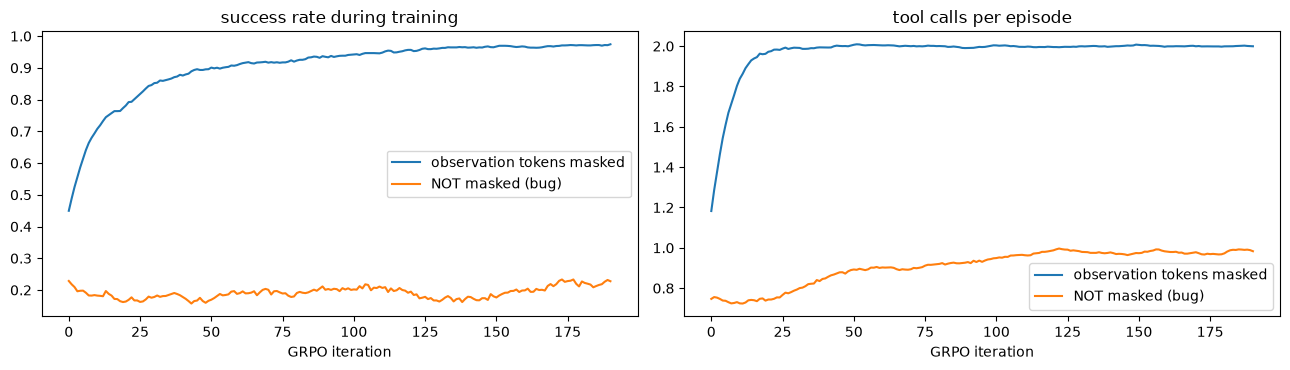

In [7]:
t0 = time.time()
agent_nomask = copy.deepcopy(base)
log_nomask = grpo(agent_nomask, mask_obs=False)
acc_nm, calls_nm, _ = evaluate(agent_nomask)
print(f"GRPO (NO mask) in {time.time() - t0:.0f}s:  success {acc_nm:.3f}, mean tool calls {calls_nm:.2f}")

sm = lambda v, w=10: np.convolve(v, np.ones(w) / w, "valid")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for log, name in [(log_masked, "observation tokens masked"), (log_nomask, "NOT masked (bug)")]:
    axes[0].plot(sm(log["reward"]), label=name)
    axes[1].plot(sm(log["calls"]), label=name)
axes[0].set_title("success rate during training"); axes[1].set_title("tool calls per episode")
for ax in axes: ax.set_xlabel("GRPO iteration"); ax.legend()
plt.tight_layout(); plt.show()

Without the mask, the agent **doesn't improve at all**. It ends up *worse*
than the base model it started from, drifting into a habit of doing exactly
one lookup, which the reward never asked for. Meanwhile the masked run climbs
to ~100%. Three effects stack up:

1. **Noise drowns the signal.** The observation-token gradient is several
   times larger than the agent-token gradient and carries no information about
   good actions. Adam normalizes the step by the gradient's overall size, so
   the useful component becomes a small fraction of each update.
2. **Dilution.** With token-mean aggregation, the agent's ~5 tokens per
   episode share the denominator with ~25 observation tokens. In real agents,
   tool outputs (pages, files, logs) can be 10–100× longer than the agent's
   actions.
3. **A second objective.** It isn't the policy gradient. It *also* trains the
   policy to predict the environment, weighted by advantages, and that pulls
   the shared weights in directions the reward never chose (here, toward one
   lookup). In
   real LLM agents that's how a model learns to *hallucinate tool
   results*: it writes a plausible `<tool_response>` itself instead of
   stopping and waiting for the real one.

That's why every agentic-RL framework carries the mask: `trl`'s `tool_mask` /
`env_mask` (notebook 16), verl's multi-turn `loss_mask`, and Search-R1's
"retrieved token masking" (which that paper ablated, reporting clear gains
from masking).

## 7. Reward design: what does a tool call cost?

Real tool calls cost money and time, so it's tempting to add a cost per call:
$R = \mathbb{1}[\text{correct}] - \lambda \cdot \#\text{calls}$. Here's what that does.

3 runs in 43s

 cost per call |  success | tool calls |  reward = success - cost x calls
           0.0 |    0.990 |       2.00 |                            0.990
           0.2 |    0.979 |       2.00 |                            0.579
           0.6 |    0.211 |       0.00 |                            0.210


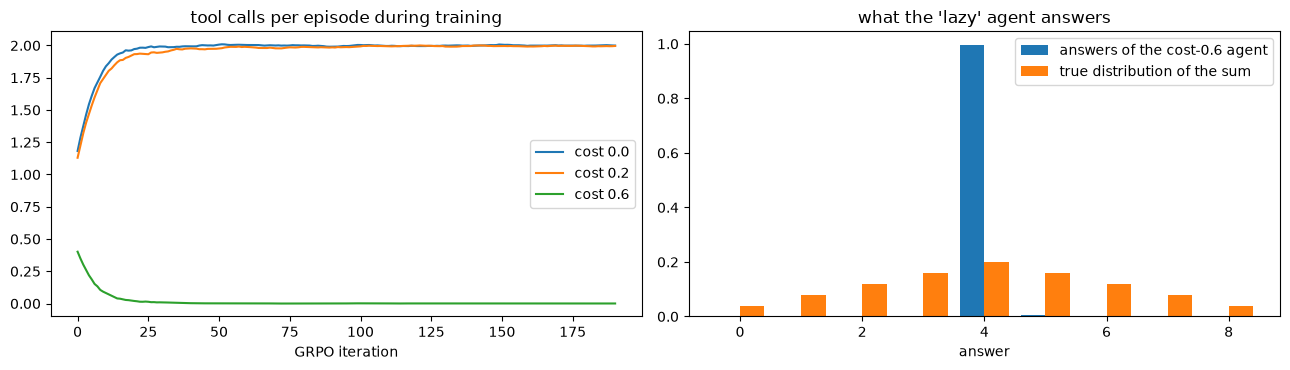

In [8]:
cost_results = {}
t0 = time.time()
for lam in [0.0, 0.2, 0.6]:
    a = copy.deepcopy(base)
    lg = grpo(a, tool_cost=lam)
    acc_l, calls_l, _ = evaluate(a)
    rng = np.random.default_rng(11)
    seqs, masks, _ = rollout(a, [make_task(rng) for _ in range(512)], rng)
    answers = [s[s.index(ANS) + 1] - DIG0 for s in seqs if ANS in s and s.index(ANS) + 1 < len(s)]
    answers = [x for x in answers if 0 <= x <= 9]                # keep well-formed digit answers
    cost_results[lam] = (acc_l, calls_l, lg, np.bincount(answers, minlength=10)[:10] / max(len(answers), 1))
print(f"3 runs in {time.time() - t0:.0f}s\n")
print(f"{'cost per call':>14} | {'success':>8} | {'tool calls':>10} | {'reward = success - cost x calls':>32}")
for lam, (a_, c_, _, _) in cost_results.items():
    print(f"{lam:>14} | {a_:>8.3f} | {c_:>10.2f} | {a_ - lam * c_:>32.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for lam, (_, _, lg, _) in cost_results.items():
    axes[0].plot(sm(lg["calls"]), label=f"cost {lam}")
axes[0].set_title("tool calls per episode during training"); axes[0].set_xlabel("GRPO iteration"); axes[0].legend()
true_dist = np.convolve(np.ones(N_VALS), np.ones(N_VALS)) / N_VALS ** 2
axes[1].bar(np.arange(9) - 0.2, cost_results[0.6][3][:9], width=0.4, label="answers of the cost-0.6 agent")
axes[1].bar(np.arange(9) + 0.2, true_dist, width=0.4, label="true distribution of the sum")
axes[1].set_title("what the 'lazy' agent answers"); axes[1].set_xlabel("answer"); axes[1].legend()
plt.tight_layout(); plt.show()

- **Cost 0.2** barely changes behavior. Two calls cost 0.4 and buy certainty
  (+0.75 over the best guess), so the agent keeps both lookups.
- **Cost 0.6** flips the trade-off. Two calls cost 1.2, *more than a correct
  answer is worth*. The agent learns to **stop using the tool entirely**, and
  answers the single most likely sum without looking anything up (the mode
  of the true distribution of the sum). It's perfectly rational for the
  reward we wrote, and useless for the task we meant.

The lesson generalizes. **An agent optimizes the reward you wrote, including
the trade-offs you didn't think about.** Tool-cost and length penalties are
useful, but should be small relative to the success reward. Many systems
instead apply them **only to successful episodes** ("among correct answers,
prefer fewer calls") or cap them, so the cheapest way to earn reward is never
"don't try."

## 8. The toy-to-real map

| this notebook | real LLM agents |
|---|---|
| `CALL k3 /CALL` | `<tool_call>{"name": "search", "arguments": {...}}</tool_call>` |
| `RES … /RES` (verbose) | `<tool_response>…</tool_response>` or a `tool` chat turn; web pages, file contents, test logs |
| forced tokens with mask 0 | the tool output appended to the context; `tool_mask` / `env_mask` / `loss_mask` = 0 |
| `MAX_CALLS`, `MAX_LEN`, reward 0 when truncated | `max_tool_calling_iterations`, `max_completion_length`; overlong filtering / soft penalties (DAPO) |
| `RES ERR /RES` on a malformed call | returning the parser's error message to the model, so it can fix its call |
| GRU hidden state, one token at a time | KV cache; in practice, generate until a stop string, then run the tool |
| SFT on a noisy teacher's mix | SFT/instruct model that sometimes uses tools well |
| outcome reward + optional tool cost | exact-match / unit tests / final-state checks, with optional efficiency terms |

## 9. Key takeaways & FAQ

**The one-paragraph summary.** A multi-turn agent rollout is a token stream
written by two authors. The rollout engine's real job is to record **who wrote
each token**. GRPO then works unchanged, with the advantage applied only to the
agent's tokens. Forgetting that mask isn't a small inefficiency: here, it
stopped learning entirely. Reward design for agents is a negotiation with an
optimizer. Make tool use too expensive, and the agent will rationally decide
not to try.

**Q1. Does the KL penalty also use the agent mask?** Yes. The KL between policy
and reference is computed per token and averaged over agent tokens only, for
the same reason: the model didn't choose the observation tokens.

**Q2. Do observation tokens still matter for training?** Yes, as *inputs*. The
forward pass reads them, and gradients flow *through* them into the hidden
states that produce later agent tokens. They're just not *targets*.

**Q3. Truncated episodes: reward 0, or drop them?** Giving 0 teaches "finish
within budget," but it also punishes good-but-long work. Dropping them (or
masking their loss, like DAPO's overlong filtering) avoids biased signals, but
can hide a real problem. A common compromise is a soft penalty that grows as the
episode nears the limit. Always **log the truncation rate**: a rising rate is
an early warning.

**Q4. Why one update per batch?** It keeps the toy simple ($\rho = 1$). With
several epochs per batch you need PPO-clip, and the importance ratios must be
computed **over agent tokens only** (notebook 17 covers off-policy effects).

**Exercises.**

1. Set `junk=(0, 0)` (no verbose output). Does the unmasked run still fail?
   What does that tell you about *why* it failed?
2. Change the SFT mix to `(0.9, 0.1, 0.0)`: the teacher never does the full
   strategy. Can RL still find it? (Notebooks 8 and 13: RL sharpens; it
   rarely invents.)
3. Implement "cost only on correct episodes": $R = \mathbb{1}[\text{correct}](1 - \lambda\cdot\#\text{calls})$
   with $\lambda = 0.3$. Does the lazy agent disappear?
4. Make the tool flaky (return `RES ERR /RES` 20% of the time). Does the agent
   learn to retry the call (notebook 13)?